# He init fixes the gradient norm while 93% of directions shrink 10× or more

Companion notebook for the article. Run all cells to reproduce every number and the figure. Needs only NumPy and matplotlib.

From [*Math for ML Engineers: From Backprop to RLHF*](https://mikaelyemane.github.io/ml-math-code/) by Mikael Yemane.

## The identity term

In [1]:
import numpy as np

d, L = 256, 50
rng = np.random.default_rng(0)
active = []                                 # active units per layer, current run

def layer_jacobian(var):
    """One ReLU layer's Jacobian D·W: Gaussian W, random half-on mask D."""
    mask = rng.random(d) < 0.5
    active.append(mask.sum())
    return mask[:, None] * rng.standard_normal((d, d)) * np.sqrt(var)

def backward(name, var, residual=False, scale=1.0):
    active.clear()
    g = rng.standard_normal(d)
    g /= np.linalg.norm(g)                  # unit gradient at the output
    P = np.eye(d)                           # running product of Jacobians
    for depth in range(1, L + 1):
        J = layer_jacobian(var)
        P = P @ (np.eye(d) + scale * J if residual else J)
        if depth in (1, 10, 50):
            s = np.linalg.svd(P, compute_uv=False)
            ok = np.mean((s > 0.1) & (s < 10))
            print(f"{name:14s} depth {depth:2d}  log10|g| {np.log10(np.linalg.norm(g @ P)):6.2f}"
                  f"  log10 smax {np.log10(s[0]):5.2f}  in [0.1,10] {ok:4.2f}"
                  + (f"  log10 smin {np.log10(s[-1]):5.2f}" if scale < 1 else ""))
    return s

backward("plain, var 1/d", 1 / d)
s_he = backward("plain, He", 2 / d)
print(f"plain, He: layer 1 keeps {active[0]} units, fewest in any layer {min(active)}, "
      f"singular values <= 1e-15 at depth 50: {np.sum(s_he <= 1e-15)}")
backward("res, scale 1", 2 / d, residual=True)
backward("res, 1/sqrt(L)", 2 / d, residual=True, scale=1 / np.sqrt(L))

plain, var 1/d depth  1  log10|g|  -0.22  log10 smax  0.20  in [0.1,10] 0.44
plain, var 1/d depth 10  log10|g|  -1.65  log10 smax -0.75  in [0.1,10] 0.03
plain, var 1/d depth 50  log10|g|  -7.45  log10 smax -6.39  in [0.1,10] 0.00
plain, He      depth  1  log10|g|   0.02  log10 smax  0.38  in [0.1,10] 0.53
plain, He      depth 10  log10|g|   0.20  log10 smax  0.92  in [0.1,10] 0.23


plain, He      depth 50  log10|g|  -0.22  log10 smax  0.85  in [0.1,10] 0.07
plain, He: layer 1 keeps 136 units, fewest in any layer 108, singular values <= 1e-15 at depth 50: 158
res, scale 1   depth  1  log10|g|   0.16  log10 smax  0.46  in [0.1,10] 0.98
res, scale 1   depth 10  log10|g|   1.51  log10 smax  2.20  in [0.1,10] 0.49
res, scale 1   depth 50  log10|g|   7.65  log10 smax  8.65  in [0.1,10] 0.12
res, 1/sqrt(L) depth  1  log10|g|  -0.00  log10 smax  0.09  in [0.1,10] 1.00  log10 smin -0.11
res, 1/sqrt(L) depth 10  log10|g|   0.03  log10 smax  0.28  in [0.1,10] 1.00  log10 smin -0.29


res, 1/sqrt(L) depth 50  log10|g|   0.22  log10 smax  0.64  in [0.1,10] 1.00  log10 smin -0.65


array([4.38594479, 4.27787026, 4.20057084, 4.18410088, 4.03872046,
       3.9282203 , 3.85099975, 3.71994354, 3.70722911, 3.54734228,
       3.52193302, 3.45810328, 3.39937483, 3.38183168, 3.35407211,
       3.2650645 , 3.18765204, 3.17286228, 3.11100928, 3.08913998,
       3.01109244, 2.95584702, 2.91835328, 2.88534331, 2.8526855 ,
       2.79834053, 2.79013258, 2.73132998, 2.67553927, 2.64948321,
       2.62786906, 2.60151333, 2.57124642, 2.55389306, 2.48847227,
       2.4593637 , 2.43757478, 2.42430903, 2.39812579, 2.38707739,
       2.35476828, 2.34281643, 2.30702074, 2.28360036, 2.27722017,
       2.23711367, 2.22339887, 2.19695637, 2.16487156, 2.13342093,
       2.1050928 , 2.08687016, 2.06663895, 2.05534083, 2.01424651,
       1.99327386, 1.97466363, 1.95631724, 1.94249336, 1.92154247,
       1.90457277, 1.88272956, 1.85991313, 1.85056796, 1.83450791,
       1.83171029, 1.81477982, 1.78009288, 1.7578528 , 1.74477854,
       1.71911159, 1.70101759, 1.69381594, 1.67277092, 1.66464

## Why 1/√L, and what a worst-case bound requires

In [2]:
for depth in (50, 200, 800):
    for scale in sorted({1 / np.sqrt(50), 1 / np.sqrt(depth)}, reverse=True):
        P = np.eye(d)
        for _ in range(depth):
            P = P @ (np.eye(d) + scale * layer_jacobian(2 / d))
        s = np.linalg.svd(P, compute_uv=False)
        print(f"L={depth:3d}  branch scale {scale:.3f}  "
              f"log10 smax {np.log10(s[0]):5.2f}  log10 smin {np.log10(s[-1]):6.2f}")

from math import comb
share = np.array([comb(L, k) / L**k for k in range(L + 1)])   # L = 50 blocks
print("share of |g|^2 from paths through k = 0..3 branches:", np.round(share[:4] / share.sum(), 3))
A_norm = np.mean([np.linalg.norm(layer_jacobian(2 / d), 2) for _ in range(10)])
print(f"||A||_2 of a masked He branch (mean of 10): {A_norm:.2f}, S at L = 50: {np.sqrt(L) * A_norm:.1f}")

L= 50  branch scale 0.141  log10 smax  0.66  log10 smin  -0.67


L=200  branch scale 0.141  log10 smax  1.52  log10 smin  -1.58


L=200  branch scale 0.071  log10 smax  0.64  log10 smin  -0.66


L=800  branch scale 0.141  log10 smax  4.35  log10 smin  -4.50


L=800  branch scale 0.035  log10 smax  0.65  log10 smin  -0.64
share of |g|^2 from paths through k = 0..3 branches: [0.372 0.372 0.182 0.058]
||A||_2 of a masked He branch (mean of 10): 2.36, S at L = 50: 16.7


## The figure

In [3]:
#@title Shared figure style (run this cell; the code can stay hidden)
"""Shared figure style for the article series.

Static PNGs for Medium/Substack (light page), 1600 x 900 px at 200 dpi.
Palette: validated categorical slots 1-3 (all-pairs pass, light mode).
Slot 3 (aqua) is below 3:1 contrast on the surface, so every series is
direct-labeled; identity never rests on color alone.
"""
import matplotlib

import matplotlib.pyplot as plt  # noqa: E402

SURFACE = "#ffffff"
INK = "#0b0b0b"          # primary text
INK_2 = "#52514e"        # secondary text, axis labels
MUTED = "#8a8985"        # tick labels, annotations
GRID = "#e8e7e3"         # recessive grid
NEUTRAL = "#b9b8b3"      # de-emphasized series / reference lines

S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
SERIES = [S1, S2, S3]

FIG_W, FIG_H, DPI = 8.0, 4.5, 200


def setup():
    plt.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titlepad": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "legend.labelcolor": INK_2,
    })


def fig(nrows=1, ncols=1, **kw):
    setup()
    return plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H), dpi=DPI, **kw)


def subtitle(ax, text):
    """Units / one-line context under the title, in secondary ink."""
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK_2,
            fontsize=10, va="bottom", ha="left")


def label_end(ax, x, y, text, color, dx=4, dy=0):
    """Direct label at a line's end, in text ink with a color key dot."""
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points",
                color=INK, fontsize=10, va="center", ha="left")


def save(f, path):
    f.tight_layout()
    f.savefig(path, dpi=DPI)
    print("wrote", path)

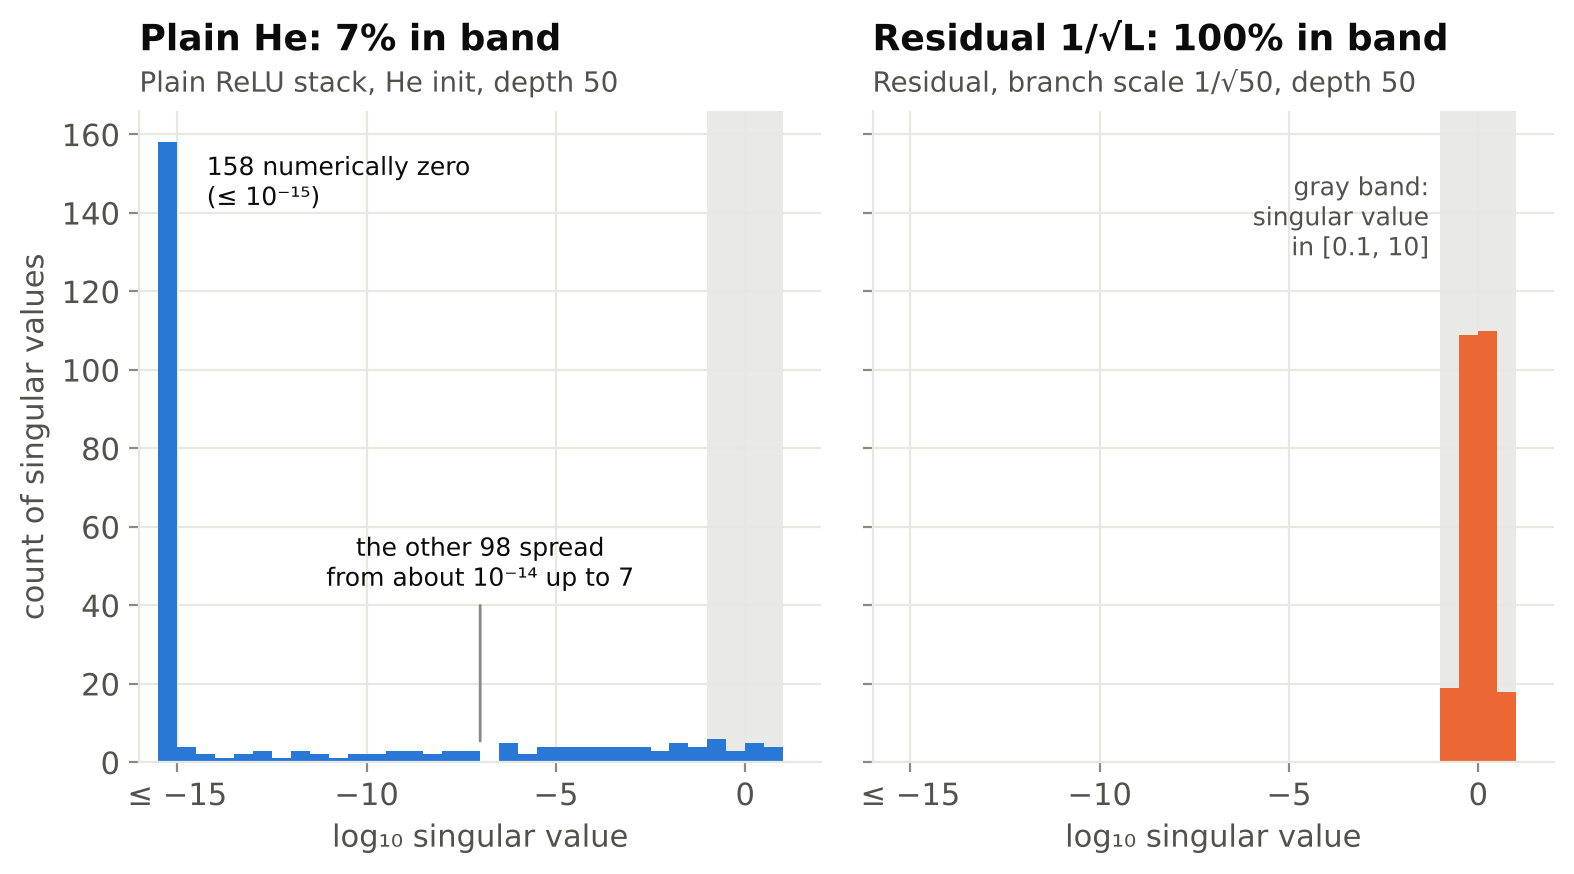

In [4]:
#@title The figure
import contextlib, io
__file__ = 'figure.py'  # the PNG is saved next to the notebook
with contextlib.redirect_stdout(io.StringIO()):  # keep the output to the chart
    import pathlib
    import numpy as np

    # Same seeded draws as the article's first code block, in the same order.
    d, L = 256, 50
    rng = np.random.default_rng(0)


    def layer_jacobian(var):
        mask = rng.random(d) < 0.5
        return mask[:, None] * rng.standard_normal((d, d)) * np.sqrt(var)


    def backward(var, residual=False, scale=1.0):
        g = rng.standard_normal(d)                 # drawn to keep the stream aligned
        P = np.eye(d)
        for _ in range(L):
            J = layer_jacobian(var)
            P = P @ (np.eye(d) + scale * J if residual else J)
        return np.linalg.svd(P, compute_uv=False)


    backward(1 / d)                                # plain, var 1/d (not plotted)
    s_he = backward(2 / d)                         # plain, He
    backward(2 / d, residual=True)                 # residual, scale 1 (not plotted)
    s_res = backward(2 / d, residual=True, scale=1 / np.sqrt(L))

    FLOOR = -15.0                                  # float64 SVD cannot resolve below ~1e-15
    bins = np.arange(FLOOR - 0.5, 2.01, 0.5)
    f, axes = fig(1, 2, sharex=True, sharey=True)
    panels = ((axes[0], s_he, S1, "Plain ReLU stack, He init", "Plain He: 7% in band"),
              (axes[1], s_res, S2, "Residual, branch scale 1/√50", "Residual 1/√L: 100% in band"))
    for ax, s, c, name, title in panels:
        with np.errstate(divide="ignore"):
            ls = np.log10(s)
        frac = np.mean((s > 0.1) & (s < 10))
        n_tiny = int(np.sum(ls <= FLOOR))
        print(f"{name}: in [0.1,10] {frac:.2f}, at or below 1e{FLOOR:.0f}: {n_tiny}, "
              f"max {ls.max():.2f}, min {ls.min():.2f}")
        ax.axvspan(-1, 1, color=NEUTRAL, alpha=0.3, lw=0, zorder=0)
        ax.hist(np.maximum(ls, FLOOR - 0.25), bins=bins, color=c, zorder=2)
        ax.set_title(title)
        subtitle(ax, f"{name}, depth 50")
        ax.set_xlabel("log₁₀ singular value")
        if n_tiny:
            ax.annotate(f"{n_tiny} numerically zero\n(≤ 10⁻¹⁵)", (FLOOR - 0.25, n_tiny),
                        xytext=(14, -4), textcoords="offset points", color=INK, fontsize=9, va="top")
            ax.annotate(f"the other {256 - n_tiny} spread\nfrom about 10⁻¹⁴ up to 7", (-7, 4), xytext=(-7, 45),
                        color=INK, fontsize=9, ha="center",
                        arrowprops=dict(arrowstyle="-", color=MUTED, lw=1))
    axes[0].set_ylabel("count of singular values")
    axes[1].text(-1.3, 150, "gray band:\nsingular value\nin [0.1, 10]", color=INK_2, fontsize=9, ha="right", va="top")
    axes[0].set_xlim(FLOOR - 1, 2)
    axes[0].set_xticks([-15, -10, -5, 0])
    axes[0].set_xticklabels(["≤ −15", "−10", "−5", "0"])
    save(f, pathlib.Path(__file__).parent / "14-backward-spectrum.png")
import matplotlib.pyplot as plt
plt.show()